#Breast Cancer Wisconsin (Diagnostic) Dataset

---

Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

In [ ]:
#Task:

#Implement a logistic regression classifier from scratch using the Breast Cancer Wisconsin dataset to predict whether a tumor is malignant or benign.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Requirements:

Data Loading and Preprocessing:
Load the Breast Cancer Wisconsin dataset
Split the data into training (80%) and testing (20%) sets
Standardize the features

Implementation Components:
Implement a sigmoid function
Implement a binary cross-entropy cost function
Implement gradient descent for weight optimization
Train the model for an appropriate number of iterations


Deliverables:
Complete Python code with proper comments
Training cost vs iterations plot
Final accuracy on test set
Comparison with scikit-learn's LogisticRegression


In [ ]:
#The radius_se feature in the Breast Cancer Wisconsin (Diagnostic) dataset represents the standard error of the mean of distances from the center to points on the contour.


1. Data Understanding

1, Understand what each feature means
2, Identify target variable
3, Check data types (numeric, categorical, date, text)
4, Understand business or real-world meaning

In [ ]:
#load dataset
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


The fractal_dimension_mean in the Breast Cancer Wisconsin (Diagnostic) dataset typically refers to the mean 'coastline approximation' of the tumor. This metric describes how irregularly the tumor boundary appears by estimating the fractal dimension of the cell nucleus contour. A higher fractal dimension indicates a more complex and irregular shape, which can be associated with malignancy.



In [ ]:
#convert diagnosis from object to numerical getdummies
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.describe()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


2. Handling Missing Values

1, Detect missing values
2, Remove rows if very few are missing
3, Fill using:

Mean / median for numerical

Mode for categorical
4, Advanced methods if required (KNN, regression)

In [ ]:
#missing values
df.isna().sum()
#no missing values

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df.drop(columns=['Unnamed: 32','id'],inplace=True)

3. Handling Duplicate Data

1, Detect duplicate rows
2, Remove duplicates to avoid bias
3, Recheck dataset size after removal

In [ ]:
#duplicates
df.duplicated().sum()
#no duplicated values

np.int64(0)

4. Handling Outliers

1, Detect using boxplot, IQR, Z-score
2, Decide whether to:

Remove

Cap

Transform
3, Domain knowledge is important here

for the TARGET(DIAGNOSIS)

In [ ]:
#histogram to understand in diagnosis or value_counts()
df['diagnosis'].value_counts()
#mild imbalance which is fine


,count
diagnosis,
0,357
1,212


FOR FEATURES

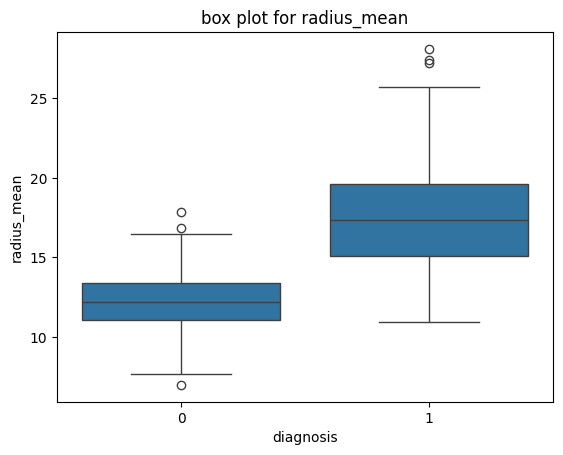

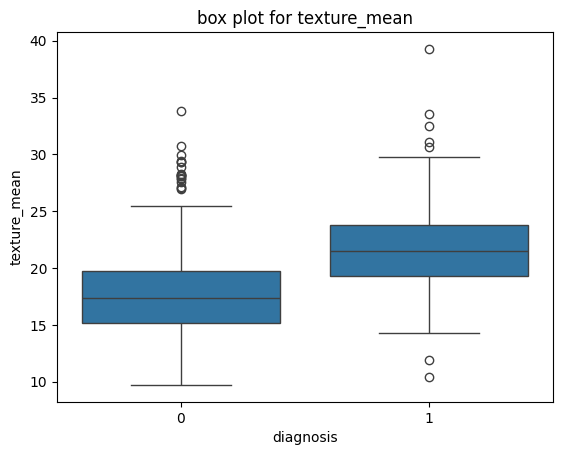

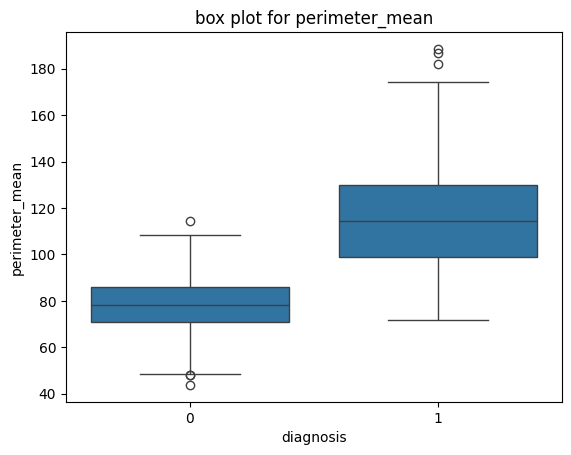

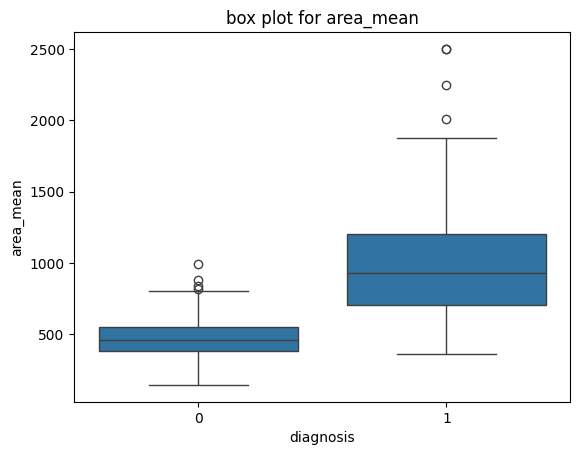

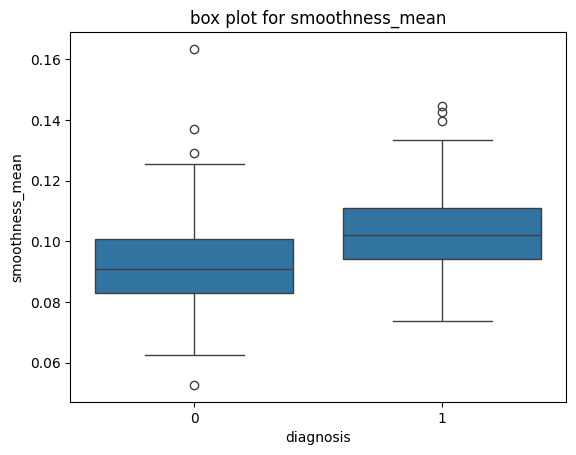

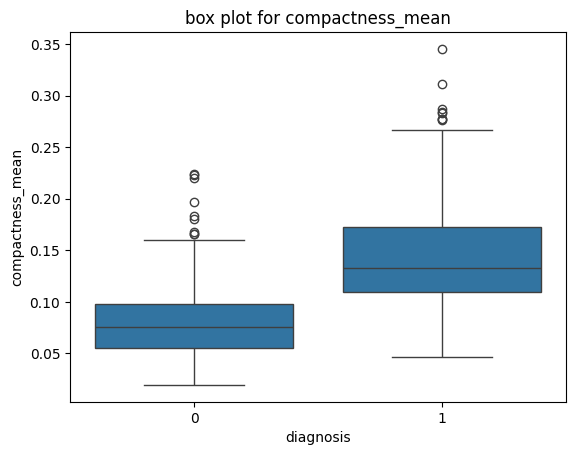

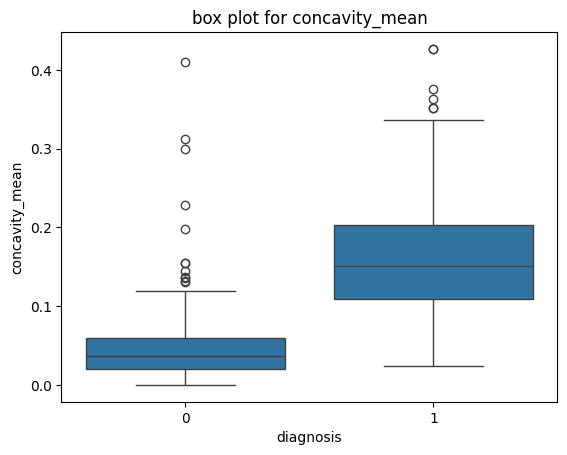

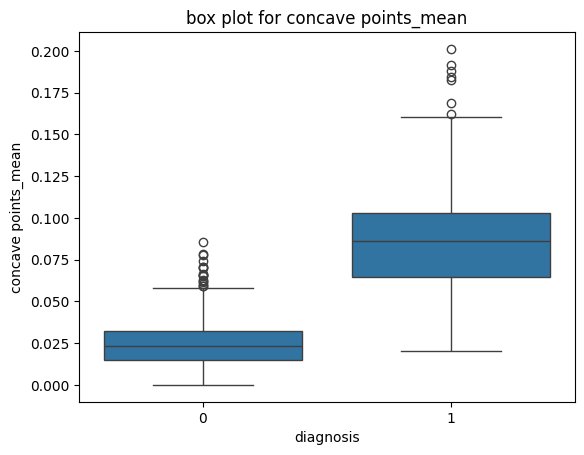

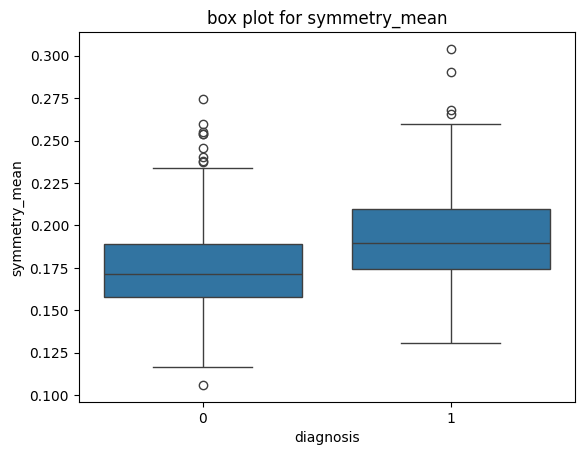

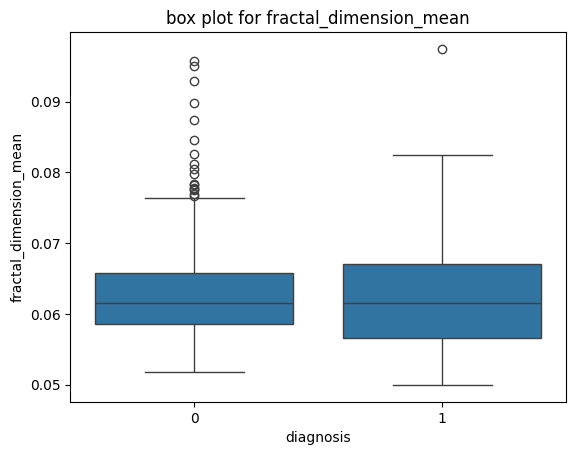

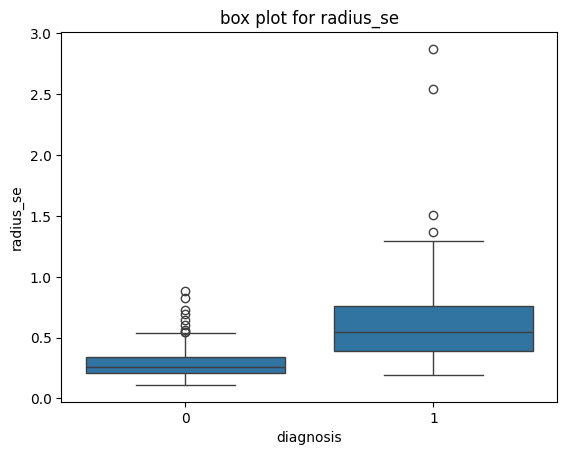

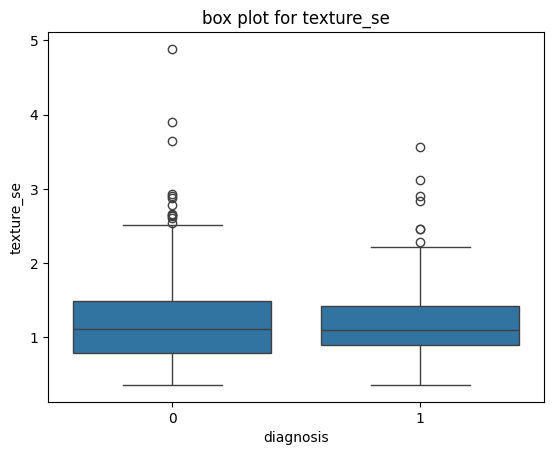

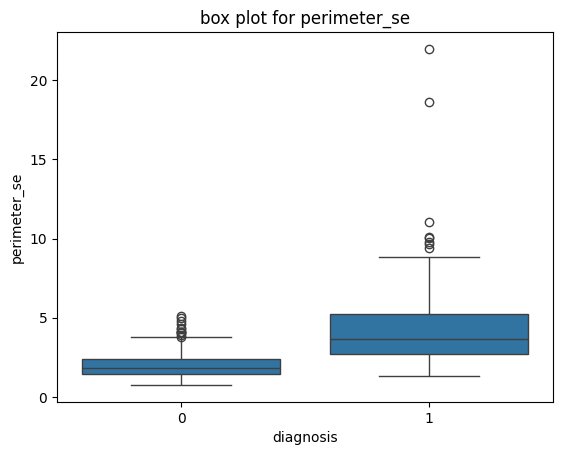

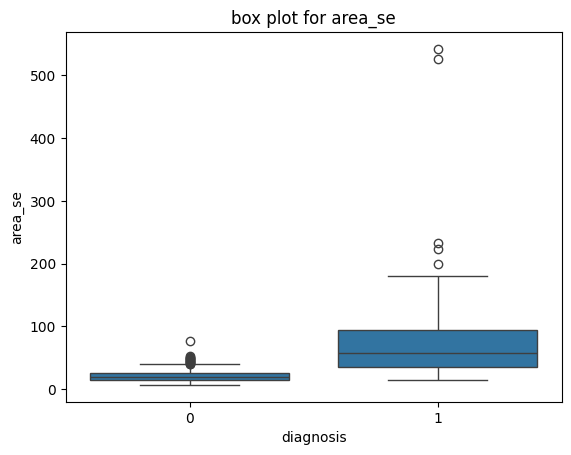

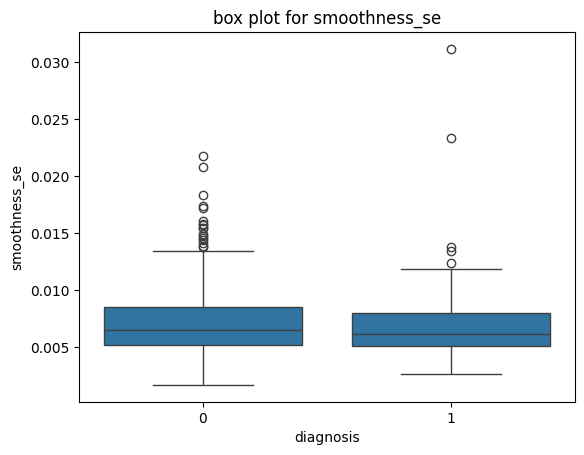

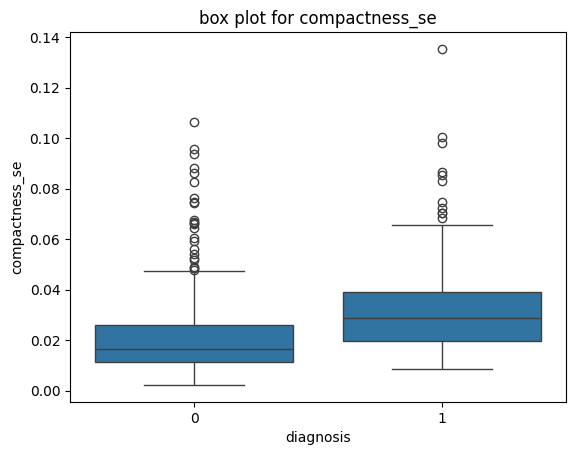

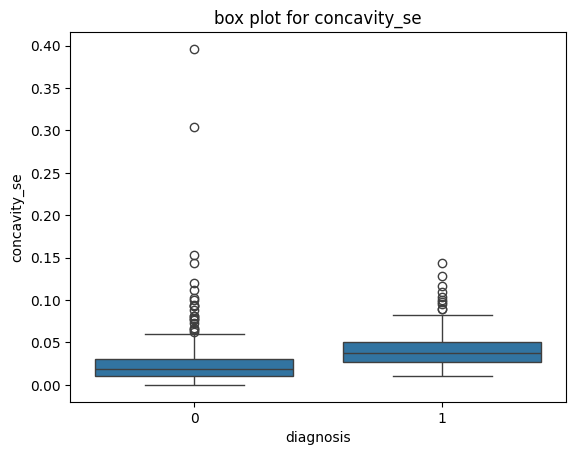

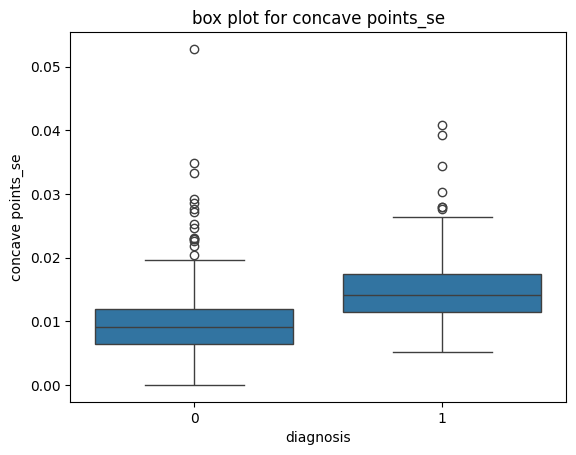

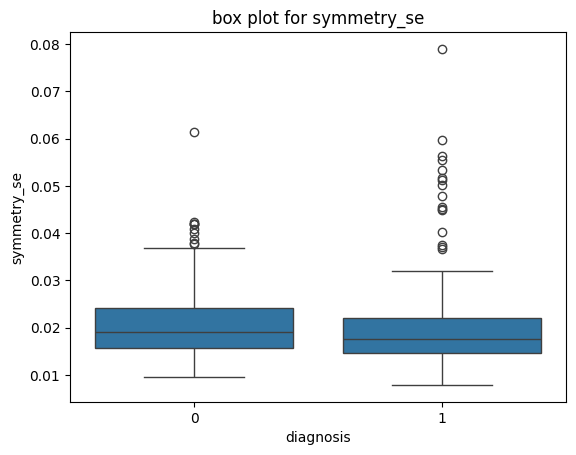

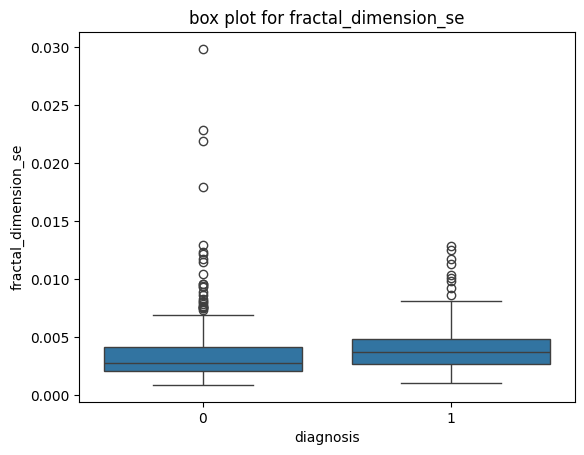

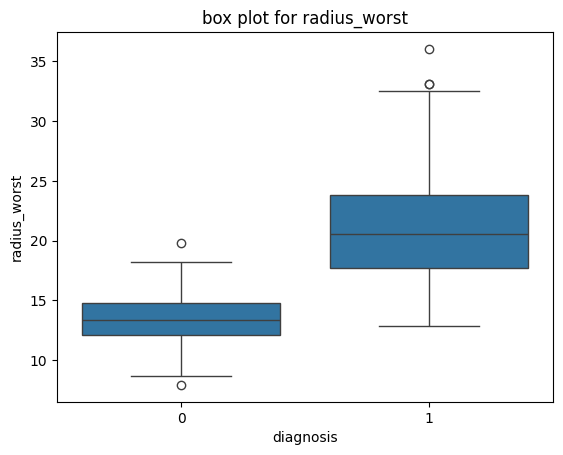

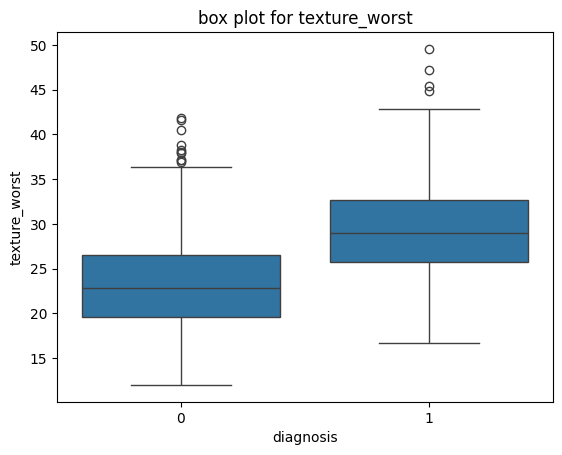

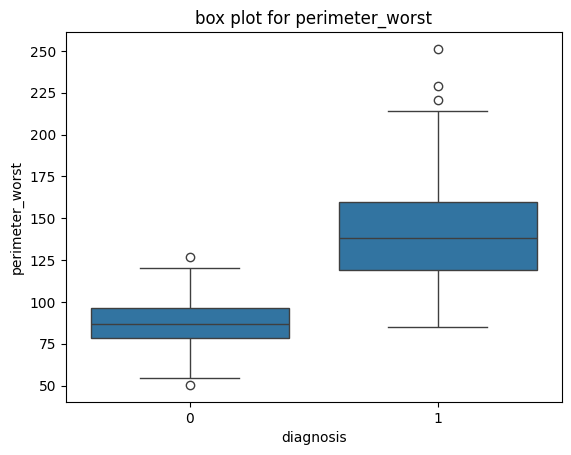

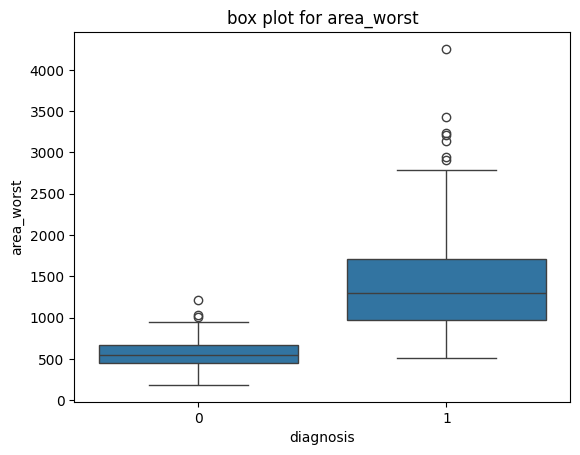

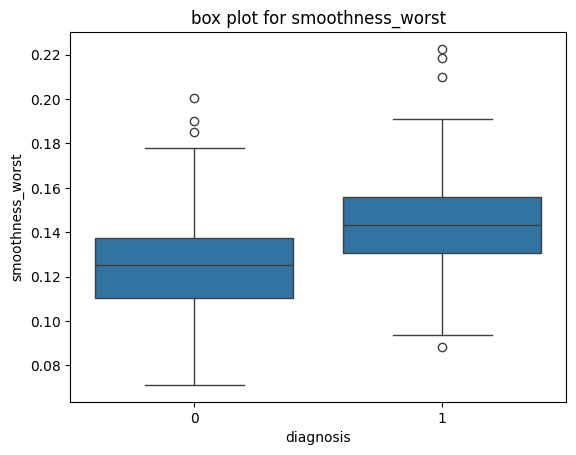

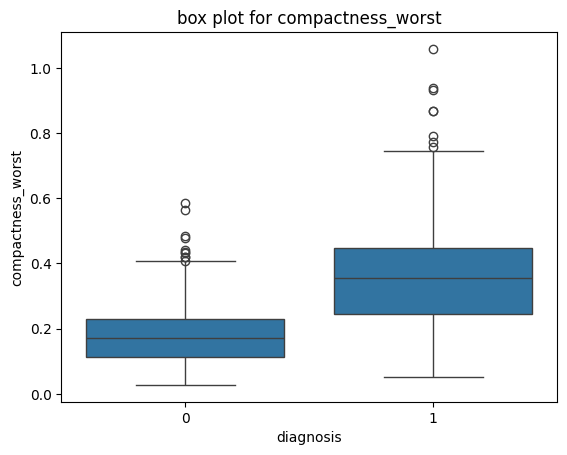

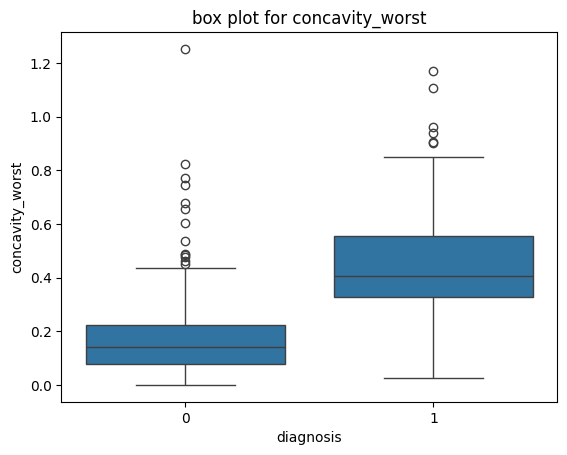

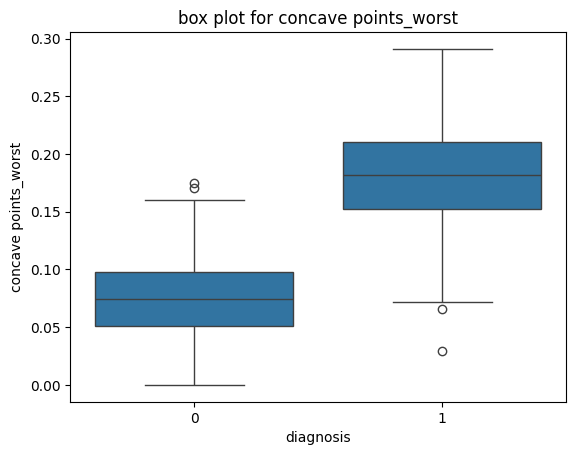

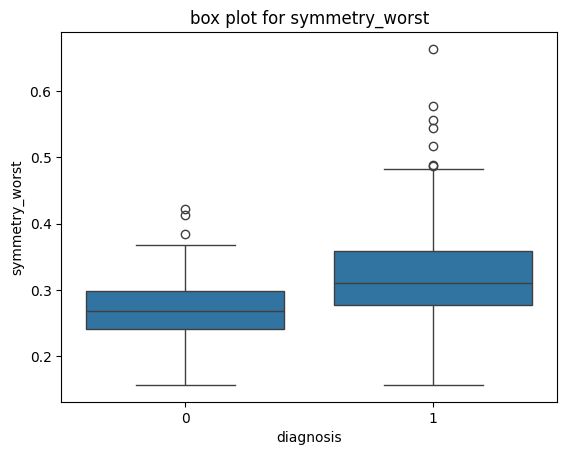

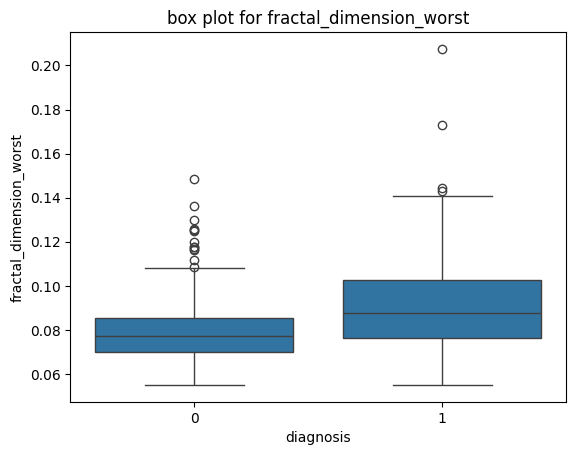

In [ ]:
#BOX PLOT FOR NUMERICAL FEATURES based on class
# 'id' and 'Unnamed: 32' were already dropped from df, so we only need to drop 'diagnosis' here.
features = df.drop(columns=['diagnosis'])
# We drop 'Unnamed: 32' because it contains only NaN values, causing issues with plotting.
features.columns.tolist()
for col in features:

  sns.boxplot(x=df["diagnosis"],y=df[col])
  plt.title(f'box plot for {col}')
  plt.show()
  """How You Interpret This Plot (Decision Rule)

After plotting:

If malignant box is much higher than benign → strong feature

If outliers appear mostly in one class → KEEP them

If both classes overlap fully → weak feature

If few random outliers in both classes → likely NOISE → can remove or cap"""

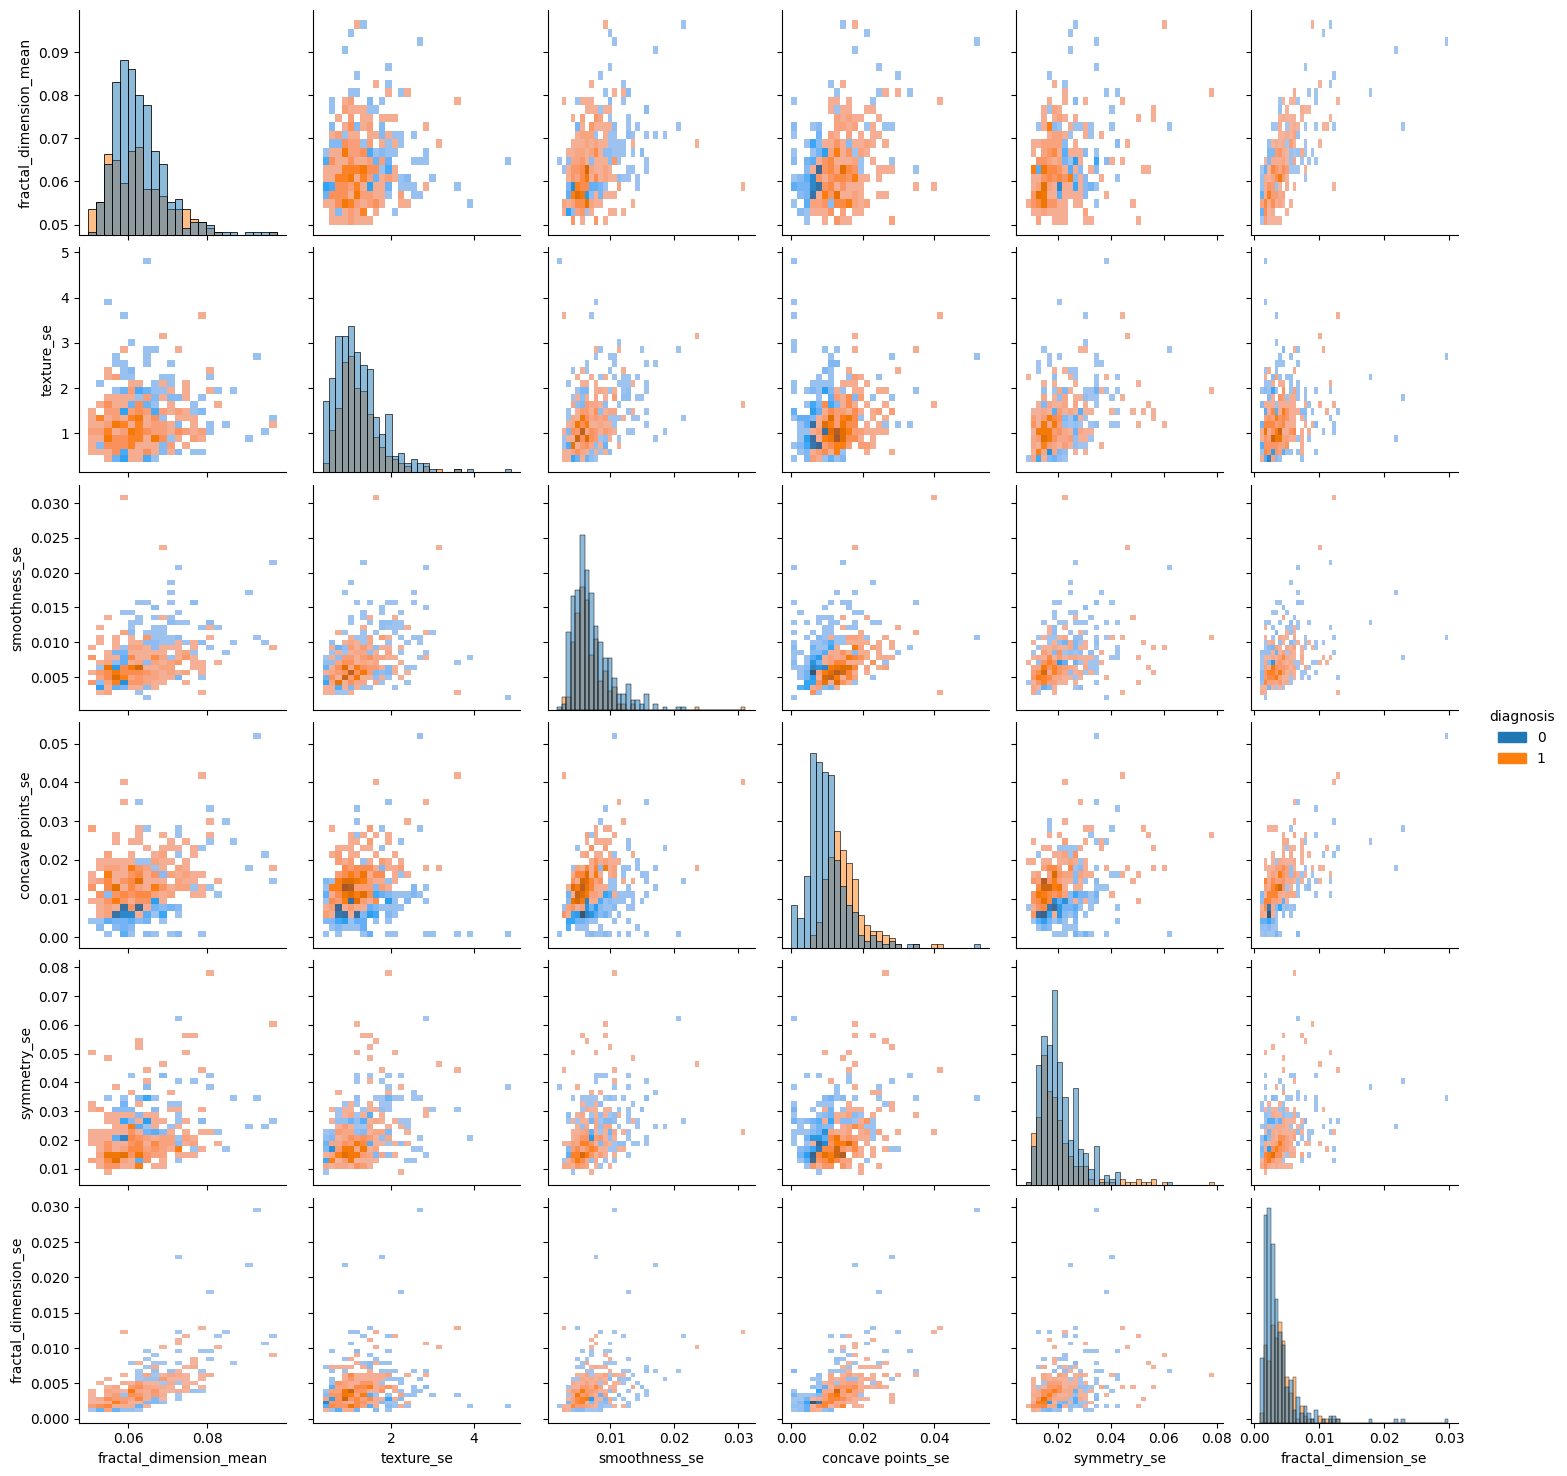

In [ ]:
#we have to do pairplot with histogram to find the skewness
import seaborn as sns
# Select the columns to plot, including 'diagnosis' for hue
selected_features = ['fractal_dimension_mean','texture_se','smoothness_se','concave points_se','symmetry_se','fractal_dimension_se']
# Create a DataFrame with only the selected features and the diagnosis column
df_for_pairplot = df[selected_features + ['diagnosis']]
sns.pairplot(df_for_pairplot, hue='diagnosis', kind="hist")
plt.show()
#these are right skewed , so i planned to use robust scalar instead of standard scalar

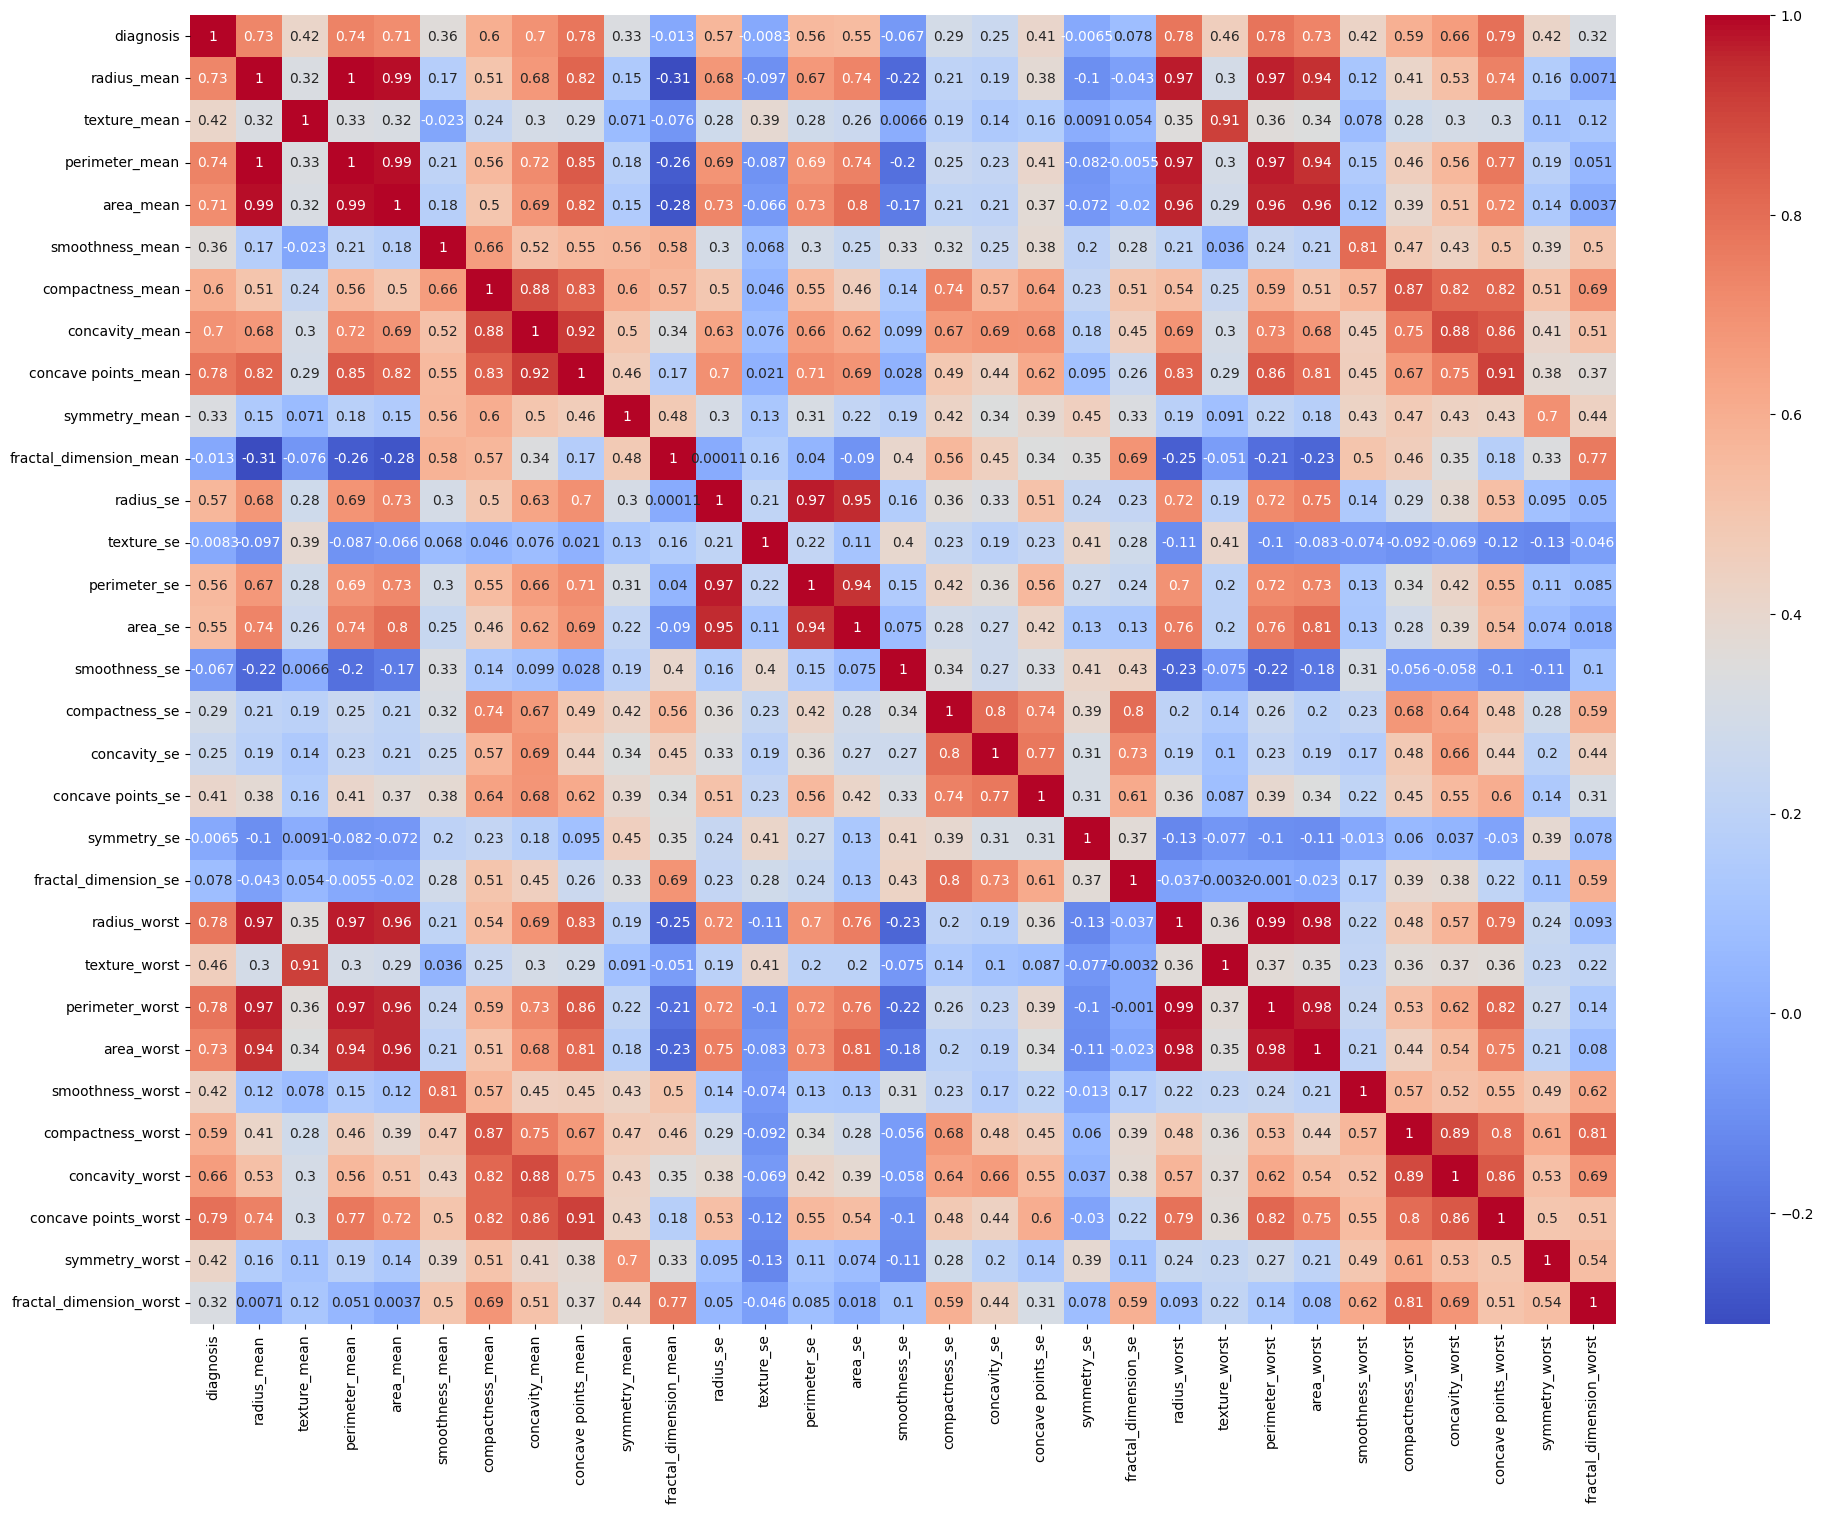

In [ ]:
#Correlation matrix
corr = df.corr()
plt.figure(figsize=(23,17))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

let us understand what groups are highly correlated between x and x >0.85
(radius_mean , perimeter_mean ,area_mean,radius_Worst,perimeter_worst,area_Worst)
keep radius_mean & worst

(texture_mean , texture_worst)
keep texture_worst

(compactness_mean,compactness_worst,concavity_mean)
keep concavity_mean

(concavity_mean&worst,concave points_mean&worst)
keep concave points_worst

(concave poins_mean&worst , perimeter_worst)
keep concave points_worst

(radius_se , perimeter&area_se)
keep radius_se

(radius_worst,perimeter&area_worst)
keep radius_worst

(compactness_worst&concavity_worst)
(concavity_worst , concave points_worst)
keep concave points_worst


Class balancing (SMOTE, oversampling, undersampling) must be done:

1, ✅ AFTER train–test split
2, ✅ ONLY on the training data
3, ✅ AFTER scaling (especially if you use SMOTE)

In [ ]:
#train test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
#let us use robust scalar to avoid the skewness
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
# X_train and X_test are numpy arrays after the train_test_split. We need to use the columns from the original X DataFrame.
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
print(X_train_scaled.head())
#

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0    -1.058488     -0.249307       -0.949040  -0.867262         0.639786   
1     1.930607      1.457064        1.979756   2.186294         1.040320   
2    -1.022800     -0.890120       -0.934729  -0.837316        -0.929773   
3    -0.656753      1.207756       -0.627225  -0.589404         0.104139   
4    -0.775713     -0.701754       -0.747993  -0.690469         1.002937   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          0.735711        2.440648             0.193073       0.939617   
1          2.809969        1.816558             2.169545       1.776141   
2         -0.050577       -0.016112            -0.216786       1.617084   
3         -0.272329       -0.366398            -0.322286       0.309278   
4         -0.151440       -0.492090            -0.382971       2.801178   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

In [ ]:
#find VIF to find collinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
# Create a temporary DataFrame without the target variable for VIF calculation
# X is already defined as df.drop(columns=['diagnosis']) and is a DataFrame
vif["features"] = X_train_scaled.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif)
#always apply vif for trained and scaled features

                   features          VIF
0               radius_mean  4295.095772
1              texture_mean    11.842919
2            perimeter_mean  4412.787760
3                 area_mean   402.836041
4           smoothness_mean     7.992139
5          compactness_mean    53.321486
6            concavity_mean    76.853375
7       concave points_mean    61.299702
8             symmetry_mean     4.171045
9    fractal_dimension_mean    17.258794
10                radius_se    83.219185
11               texture_se     4.297505
12             perimeter_se    80.121600
13                  area_se    44.641999
14            smoothness_se     3.881611
15           compactness_se    16.206901
16             concavity_se    16.801326
17        concave points_se    12.360157
18              symmetry_se     5.571329
19     fractal_dimension_se    10.263197
20             radius_worst   849.652515
21            texture_worst    18.135000
22          perimeter_worst   470.683700
23              

In [ ]:
#valuecounts
df['diagnosis'].value_counts()
#let us us

,count
diagnosis,
0,357
1,212


37% malignant is NOT a case for undersampling. It is a mild imbalance where you either do nothing

you must NOT drop everything at once — you do this iteratively and intelligently via VIF

drop() does NOT modify the DataFrame by default

You wrote:

X_train_scaled.drop(columns=[...])
X_test_scaled.drop(columns=[...])


This returns a new DataFrame, but you did not store it back.

"""Low correlation with the target is NOT a valid reason for iterative feature removal. Use VIF to remove redundancy and L1/Random Forest to remove weak predictors."""

In [ ]:
#vif = pd.DataFrame()
# Create a temporary DataFrame without the target variable for VIF calculation
# X is already defined as df.drop(columns=['diagnosis']) and is a DataFrame
#X_train_scaled = X_train_scaled.drop(columns=["fractal_dimension_mean","texture_se","smoothness_se","symmetry_se","fractal_dimension_se"], errors='ignore')
#X_test_scaled = X_test_scaled.drop(columns=["fractal_dimension_mean","texture_se","smoothness_se","symmetry_se","fractal_dimension_se"], errors='ignore')

#these are not fairly correlated with target (y)
#vif["features"] = X_train_scaled.columns
#vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
#print(vif)

let us understand what groups are highly correlated between x and x >0.85
(radius_mean , perimeter_mean ,area_mean,radius_Worst,perimeter_worst,area_Worst)
keep radius_mean & worst

(texture_mean , texture_worst)
keep texture_worst

(compactness_mean,compactness_worst,concavity_mean)
keep concavity_mean

(concavity_mean&worst,concave points_mean&worst)
keep concave points_worst

(concave poins_mean&worst , perimeter_worst)
keep concave points_worst

(radius_se , perimeter&area_se)
keep radius_se

(radius_worst,perimeter&area_worst)
keep radius_worst

(compactness_worst&concavity_worst)
(concavity_worst , concave points_worst)
keep concave points_worst

In [ ]:
#drop high correlated within features via vif method :
#GROUP 1
#(radius_mean , perimeter_mean ,area_mean,radius_Worst,perimeter_worst,area_Worst) keep radius_mean & worst
X_train_scaled = X_train_scaled.drop(columns=["perimeter_mean","area_mean"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["perimeter_mean","area_mean"], errors='ignore')
vif = pd.DataFrame() # Re-initialize the vif DataFrame
vif["features"] = X_train_scaled.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif)

                   features         VIF
0               radius_mean   58.260873
1              texture_mean   11.690672
2           smoothness_mean    7.817116
3          compactness_mean   33.190362
4            concavity_mean   70.680213
5       concave points_mean   60.872243
6             symmetry_mean    4.131407
7    fractal_dimension_mean   16.658506
8                 radius_se   81.442836
9                texture_se    4.174392
10             perimeter_se   73.629865
11                  area_se   41.792813
12            smoothness_se    3.816599
13           compactness_se   16.189317
14             concavity_se   15.431961
15        concave points_se   11.328476
16              symmetry_se    5.515045
17     fractal_dimension_se   10.158963
18             radius_worst  507.050822
19            texture_worst   17.772026
20          perimeter_worst  371.443902
21               area_worst  124.673554
22         smoothness_worst   10.424404
23        compactness_worst   35.703690


In [ ]:
#drop high correlated within features via vif method :
#GROUP 1
#(radius_mean , perimeter_mean ,area_mean,radius_Worst,perimeter_worst,area_Worst) keep radius_mean & worst
X_train_scaled = X_train_scaled.drop(columns=["perimeter_worst","area_worst"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["perimeter_worst","area_worst"], errors='ignore')
vif = pd.DataFrame() # Re-initialize the vif DataFrame
vif["features"] = X_train_scaled.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif)

                   features        VIF
0               radius_mean  40.131649
1              texture_mean  11.614873
2           smoothness_mean   7.644946
3          compactness_mean  31.420323
4            concavity_mean  70.526876
5       concave points_mean  58.478419
6             symmetry_mean   4.066968
7    fractal_dimension_mean  15.142137
8                 radius_se  44.790053
9                texture_se   4.113607
10             perimeter_se  35.823163
11                  area_se  19.969430
12            smoothness_se   3.779484
13           compactness_se  16.008645
14             concavity_se  15.425973
15        concave points_se  11.181703
16              symmetry_se   5.395562
17     fractal_dimension_se   9.772745
18             radius_worst  45.653941
19            texture_worst  17.562812
20         smoothness_worst  10.354239
21        compactness_worst  33.345950
22          concavity_worst  32.101921
23     concave points_worst  38.285841
24           symmetry_wor

In [ ]:
#

In [ ]:
#drop high correlated within features via vif method :
#GROUP 2
#(texture_mean , texture_worst) keep texture_worst
X_train_scaled = X_train_scaled.drop(columns=["texture_mean"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["texture_mean"], errors='ignore')
vif = pd.DataFrame() # Re-initialize the vif DataFrame
vif["features"] = X_train_scaled.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif)

                   features        VIF
0               radius_mean  39.578566
1           smoothness_mean   7.641506
2          compactness_mean  31.392738
3            concavity_mean  70.525405
4       concave points_mean  58.052552
5             symmetry_mean   3.980897
6    fractal_dimension_mean  15.040818
7                 radius_se  44.239702
8                texture_se   3.080661
9              perimeter_se  35.674353
10                  area_se  19.900294
11            smoothness_se   3.644750
12           compactness_se  15.885463
13             concavity_se  15.421941
14        concave points_se  10.906197
15              symmetry_se   5.004714
16     fractal_dimension_se   9.750673
17             radius_worst  45.441481
18            texture_worst   2.509212
19         smoothness_worst   9.887982
20        compactness_worst  32.883231
21          concavity_worst  32.101885
22     concave points_worst  36.805721
23           symmetry_worst   8.651819
24  fractal_dimension_wor

let us understand what groups are highly correlated between x and x >0.85
(radius_mean , perimeter_mean ,area_mean,radius_Worst,perimeter_worst,area_Worst)
keep radius_mean & worst

(texture_mean , texture_worst)
keep texture_worst

(compactness_mean,compactness_worst,concavity_mean)
keep concavity_mean

(concavity_mean&worst,concave points_mean&worst)
keep concave points_worst

(concave poins_mean&worst , perimeter_worst)
keep concave points_worst

(radius_se , perimeter&area_se)
keep radius_se

(radius_worst,perimeter&area_worst)
keep radius_worst

(compactness_worst&concavity_worst)
(concavity_worst , concave points_worst)
keep concave points_worst

In [ ]:
#drop high correlated within features via vif method :
#GROUP 2 & 3
#(compactness_mean,compactness_worst,concavity_mean) keep concavity_mean
X_train_scaled = X_train_scaled.drop(columns=["compactness_mean","compactness_worst","concavity_mean"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["compactness_mean","compactness_worst","concavity_mean"], errors='ignore')
vif = pd.DataFrame() # Re-initialize the vif DataFrame
vif["features"] = X_train_scaled.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif)

                   features        VIF
0               radius_mean  36.957901
1           smoothness_mean   7.049927
2       concave points_mean  22.997146
3             symmetry_mean   3.769930
4    fractal_dimension_mean  10.759727
5                 radius_se  44.048270
6                texture_se   2.990226
7              perimeter_se  34.726832
8                   area_se  18.422139
9             smoothness_se   3.567342
10           compactness_se   6.959687
11             concavity_se  10.917140
12        concave points_se  10.109342
13              symmetry_se   4.979156
14     fractal_dimension_se   8.538316
15             radius_worst  43.611784
16            texture_worst   2.471994
17         smoothness_worst   9.804178
18          concavity_worst  17.331037
19     concave points_worst  32.981867
20           symmetry_worst   8.475781
21  fractal_dimension_worst  13.810908


In [ ]:
#drop high correlated within features via vif method :
#GROUP 2 & 3
#(concavity_mean&worst,concave points_mean&worst)keep concave points_worst
X_train_scaled = X_train_scaled.drop(columns=["concave points_mean","concavity_worst"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["concave points_mean","concavity_worst"], errors='ignore')
vif = pd.DataFrame() # Re-initialize the vif DataFrame
vif["features"] = X_train_scaled.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif)

                   features        VIF
0               radius_mean  33.420676
1           smoothness_mean   6.508007
2             symmetry_mean   3.706183
3    fractal_dimension_mean   9.340345
4                 radius_se  43.775791
5                texture_se   2.953290
6              perimeter_se  34.045608
7                   area_se  18.180403
8             smoothness_se   3.317375
9            compactness_se   6.606826
10             concavity_se   4.577297
11        concave points_se   7.845104
12              symmetry_se   4.932429
13     fractal_dimension_se   7.396243
14             radius_worst  43.608397
15            texture_worst   2.452728
16         smoothness_worst   9.350653
17     concave points_worst  16.745947
18           symmetry_worst   8.290662
19  fractal_dimension_worst  10.681281


In [ ]:
#drop high correlated within features via vif method :
#GROUP 6
#(radius_se , perimeter&area_se)keep radius_se
X_train_scaled = X_train_scaled.drop(columns=["perimeter_se","area_se"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["perimeter_se","area_se"], errors='ignore')
vif = pd.DataFrame() # Re-initialize the vif DataFrame
vif["features"] = X_train_scaled.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif)

                   features        VIF
0               radius_mean  29.960474
1           smoothness_mean   6.381659
2             symmetry_mean   3.686728
3    fractal_dimension_mean   9.116869
4                 radius_se   4.811482
5                texture_se   2.930404
6             smoothness_se   3.215050
7            compactness_se   6.109717
8              concavity_se   4.291583
9         concave points_se   6.648538
10              symmetry_se   4.895915
11     fractal_dimension_se   6.525784
12             radius_worst  39.930402
13            texture_worst   2.450788
14         smoothness_worst   9.348528
15     concave points_worst  16.600151
16           symmetry_worst   8.279345
17  fractal_dimension_worst  10.543111


In [ ]:
#drop high correlated within features via vif method :
#GROUP 7
#(radius_mean , radius_worst)keep radius_mean
# The creation of 'radius_mean_worst' and dropping both was not aligned with the instruction.
# Instead, we will directly drop 'radius_mean' to keep 'radius_worst'.
X_train_scaled = X_train_scaled.drop(columns=["radius_worst"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["radius_worst"], errors='ignore')

vif = pd.DataFrame() # Re-initialize the vif DataFrame
vif["features"] = X_train_scaled.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif)

                   features        VIF
0               radius_mean   8.458147
1           smoothness_mean   6.210978
2             symmetry_mean   3.574859
3    fractal_dimension_mean   9.092598
4                 radius_se   3.106454
5                texture_se   2.929426
6             smoothness_se   3.206747
7            compactness_se   6.092744
8              concavity_se   4.260961
9         concave points_se   6.552304
10              symmetry_se   4.620391
11     fractal_dimension_se   6.454516
12            texture_worst   2.433728
13         smoothness_worst   9.219835
14     concave points_worst  15.689132
15           symmetry_worst   7.767043
16  fractal_dimension_worst  10.503589


In [ ]:
#drop high correlated within features via vif method :
#GROUP 8
#(compactness_worst&concavity_worst)(concavity_worst , concave points_worst)keep concave points_worst
X_train_scaled = X_train_scaled.drop(columns=["radius_worst"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["radius_worst"], errors='ignore')

vif = pd.DataFrame() # Re-initialize the vif DataFrame
vif["features"] = X_train_scaled.columns
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif)

                   features        VIF
0               radius_mean   8.458147
1           smoothness_mean   6.210978
2             symmetry_mean   3.574859
3    fractal_dimension_mean   9.092598
4                 radius_se   3.106454
5                texture_se   2.929426
6             smoothness_se   3.206747
7            compactness_se   6.092744
8              concavity_se   4.260961
9         concave points_se   6.552304
10              symmetry_se   4.620391
11     fractal_dimension_se   6.454516
12            texture_worst   2.433728
13         smoothness_worst   9.219835
14     concave points_worst  15.689132
15           symmetry_worst   7.767043
16  fractal_dimension_worst  10.503589


NOW WORKABLE VIF values , so we can proceed for L1 regulization ...

#1)SKLEARN MODEL LOGISTIC

In [ ]:
#L1 regulization for x_train_scaled
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
C = [0.1,1,2,4,6,8,10]
for c in C:
 L1_reg = LogisticRegression(penalty='l1', solver='liblinear', C=c, random_state=42)
 L1_reg.fit(X_train_scaled, y_train)
  #✅ Recall for malignant is good
  #✅ Number of features is stable

 kept =   (L1_reg.coef_[0] != 0).sum()
 print(f"C={c} , features kept:{kept}")

 #let us use cv=recall
 from sklearn.model_selection import cross_val_score
 scores = cross_val_score(L1_reg, X_train_scaled, y_train, cv=5, scoring='recall')
 print(f"C={c} , recall scores:{scores.mean()}")

 #same for f1 score
 scores = cross_val_score(L1_reg, X_train_scaled, y_train, cv=5, scoring='f1')
 print(f"C={c} , f1 scores:{scores.mean()}")


#C=6 gives max f1 and 2nd highest recall which is good , since we have removed many features using VIF ..so it's fine

C=0.1 , features kept:7
C=0.1 , recall scores:0.9292335115864528
C=0.1 , f1 scores:0.9485077952483572
C=1 , features kept:13
C=1 , recall scores:0.9411764705882352
C=1 , f1 scores:0.9546741815398532
C=2 , features kept:13
C=2 , recall scores:0.9470588235294116
C=2 , f1 scores:0.9606512890094979
C=4 , features kept:13
C=4 , recall scores:0.9470588235294116
C=4 , f1 scores:0.9579375848032564
C=6 , features kept:15
C=6 , recall scores:0.9529411764705884
C=6 , f1 scores:0.9611035730438715
C=8 , features kept:15
C=8 , recall scores:0.9529411764705884
C=8 , f1 scores:0.9584696836672254
C=10 , features kept:15
C=10 , recall scores:0.9588235294117649
C=10 , f1 scores:0.956001207633074


In [ ]:
L1_reg_temp = LogisticRegression(penalty='l1', solver='liblinear', C=6, random_state=42)
L1_reg_temp.fit(X_train_scaled, y_train)

final_features = X_train_scaled.columns[L1_reg_temp.coef_[0] != 0]
removed = X_train_scaled.columns[L1_reg_temp.coef_[0] == 0]

print(final_features)
print(removed)

X_train_final = X_train_scaled[final_features]
X_test_final = X_test_scaled[final_features]

# Now, train the L1_reg_best model on the final selected features
L1_reg_best = LogisticRegression(penalty='l1', solver='liblinear', C=6, random_state=42)
L1_reg_best.fit(X_train_final, y_train)

Index(['radius_mean', 'smoothness_mean', 'symmetry_mean',
       'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'symmetry_se', 'fractal_dimension_se',
       'texture_worst', 'smoothness_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='object')
Index(['concave points_se', 'fractal_dimension_worst'], dtype='object')


LogisticRegression(C=6, penalty='l1', random_state=42, solver='liblinear')

In [ ]:
#we shall use this L1_reg_best as final_model
from sklearn.metrics import classification_report, accuracy_score ,roc_auc_score
final_model = L1_reg_best
y_pred = final_model.predict(X_test_final)
accuracy = accuracy_score(y_test, y_pred)
classification = classification_report(y_test, y_pred)
y_prob = final_model.predict_proba(X_test_final)[:, 1]
print(f"Accuracy: {accuracy}")
print(f"classification report:{classification}")
print(f"roc-auc:{roc_auc_score(y_test,y_prob)}")


Accuracy: 0.9736842105263158
classification report:              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

roc-auc:0.9963969865705864


#ii)now manual model

# Task
Implement a Python function that computes the sigmoid activation given an input `z` for the custom Logistic Regression model.

## Implement Sigmoid Function

### Subtask:
Create a Python function that computes the sigmoid activation given an input z.


**Reasoning**:
Implement the sigmoid function as described in the instructions, ensuring numpy is used for exponential calculation.



In [ ]:
import numpy as np

def sigmoid(z):
    """
    Computes the sigmoid activation of the input z.

    Args:
        z (float or np.ndarray): The input to the sigmoid function.

    Returns:
        float or np.ndarray: The sigmoid activation of z.
    """
    return 1 / (1 + np.exp(-z))

print("Sigmoid function defined successfully.")


Sigmoid function defined successfully.


## Implement Binary Cross-Entropy Cost Function

### Subtask:
Develop a Python function to calculate the binary cross-entropy loss between predicted probabilities and true labels.


**Reasoning**:
Implement the binary cross-entropy cost function as described in the instructions, ensuring numpy is used for logarithmic calculations and handling potential log(0) issues.



In [ ]:
def binary_cross_entropy_cost(y_true, y_pred):
    """
    Calculates the binary cross-entropy loss.

    Args:
        y_true (np.ndarray): True labels (0 or 1).
        y_pred (np.ndarray): Predicted probabilities (between 0 and 1).

    Returns:
        float: The average binary cross-entropy loss.
    """
    # Add a small constant to y_pred to avoid log(0)
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon) # Clip values to avoid issues with log(0) or log(1)

    cost = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return cost

print("Binary cross-entropy cost function defined successfully.")

Binary cross-entropy cost function defined successfully.


## Implement Custom Logistic Regression Class

### Subtask:
Create a Python class for Logistic Regression that includes methods for initializing weights, fitting the model using gradient descent (iteratively updating weights and bias), and making predictions. This class should also store the cost at each iteration.


**Reasoning**:
I will implement the `LogisticRegressionCustom` class, including `__init__`, `fit`, and `predict` methods, as specified in the instructions. This class will encapsulate the logic for initializing parameters, training the model using gradient descent, and making predictions.



# Task
I will now implement the `LogisticRegressionCustom` class, ensuring each method (`__init__`, `fit`, `predict`) is well-commented to explain its functionality, as per the plan.

```python
class LogisticRegressionCustom:
    """
    A custom implementation of Logistic Regression using Gradient Descent.
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Initializes the LogisticRegressionCustom model.

        Args:
            learning_rate (float): The step size for updating weights and bias during gradient descent.
            n_iterations (int): The number of iterations (epochs) to run the gradient descent optimization.
        """
        # Initialize learning rate for gradient descent
        self.learning_rate = learning_rate
        # Initialize number of iterations for training
        self.n_iterations = n_iterations
        # Weights (coefficients) of the logistic regression model, initialized to None
        self.weights = None
        # Bias (intercept) of the logistic regression model, initialized to None
        self.bias = None
        # List to store the cost (loss) at each iteration during training
        self.cost_history = []

    def fit(self, X, y):
        """
        Fits the logistic regression model to the training data using gradient descent.

        Args:
            X (np.ndarray): Training features (design matrix), shape (n_samples, n_features).
            y (np.ndarray): True labels for the training data, shape (n_samples,).
        """
        n_samples, n_features = X.shape

        # Initialize weights and bias to zeros
        # Weights are initialized as a column vector (n_features, 1)
        self.weights = np.zeros((n_features, 1))
        # Bias is initialized as a scalar
        self.bias = 0

        # Reshape y to be a column vector (n_samples, 1) for consistent matrix operations
        y = y.reshape(-1, 1)

        # Gradient Descent optimization loop
        for i in range(self.n_iterations):
            # Calculate the linear combination of inputs and weights: z = X * w + b
            z = np.dot(X, self.weights) + self.bias
            # Apply the sigmoid function to get predicted probabilities (y_pred)
            y_pred = sigmoid(z)

            # Calculate the gradients of the cost function with respect to weights and bias
            # Gradient of weights: (1/n_samples) * X_transpose * (y_pred - y_true)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            # Gradient of bias: (1/n_samples) * sum(y_pred - y_true)
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update weights and bias using the learning rate
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate and store the cost (binary cross-entropy loss) for the current iteration
            cost = binary_cross_entropy_cost(y, y_pred)
            self.cost_history.append(cost)

            # Print cost periodically to monitor training progress
            if i % (self.n_iterations // 10) == 0:
                print(f"Iteration {i}: Cost = {cost}")

    def predict(self, X):
        """
        Predicts binary labels (0 or 1) for new input data.

        Args:
            X (np.ndarray): Test features (design matrix), shape (n_samples, n_features).

        Returns:
            np.ndarray: Predicted binary labels, shape (n_samples,).
        """
        # Calculate the linear combination of inputs and weights: z = X * w + b
        z = np.dot(X, self.weights) + self.bias
        # Apply the sigmoid function to get predicted probabilities
        y_pred_proba = sigmoid(z)
        # Convert probabilities to binary predictions (0 or 1) based on a threshold of 0.5
        y_predicted = (y_pred_proba >= 0.5).astype(int)
        # Reshape predictions to a 1D array
        return y_predicted.flatten()

print("LogisticRegressionCustom class defined successfully.")
```

**Reasoning**:
I will define the `LogisticRegressionCustom` class, which encapsulates the logic for initializing parameters, training the model using gradient descent, and making predictions, while also storing the cost at each iteration.



## Review and Comment Custom Logistic Regression Class Implementation

### Subtask:
Review the existing code for the `LogisticRegressionCustom` class and add detailed comments explaining each part of the `__init__`, `fit`, and `predict` methods. This will ensure clarity and adherence to the requirement of explaining code via comments.


**Reasoning**:
The subtask requires reviewing and commenting on the `LogisticRegressionCustom` class. The provided notebook has a well-commented version in a markdown cell. I will extract this version, convert it to a code cell, ensure `cost_history` is used, and then execute it to define the class.



In [ ]:
class LogisticRegressionCustom:
    """
    A custom implementation of Logistic Regression using Gradient Descent.
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Initializes the LogisticRegressionCustom model.

        Args:
            learning_rate (float): The step size for updating weights and bias during gradient descent.
            n_iterations (int): The number of iterations (epochs) to run the gradient descent optimization.
        """
        # Initialize learning rate for gradient descent
        self.learning_rate = learning_rate
        # Initialize number of iterations for training
        self.n_iterations = n_iterations
        # Weights (coefficients) of the logistic regression model, initialized to None
        self.weights = None
        # Bias (intercept) of the logistic regression model, initialized to None
        self.bias = None
        # List to store the cost (loss) at each iteration during training
        self.cost_history = []

    def fit(self, X, y):
        """
        Fits the logistic regression model to the training data using gradient descent.

        Args:
            X (np.ndarray): Training features (design matrix), shape (n_samples, n_features).
            y (np.ndarray): True labels for the training data, shape (n_samples,).
        """
        n_samples, n_features = X.shape

        # Initialize weights and bias to zeros
        # Weights are initialized as a column vector (n_features, 1)
        self.weights = np.zeros((n_features, 1))
        # Bias is initialized as a scalar
        self.bias = 0

        # Reshape y to be a column vector (n_samples, 1) for consistent matrix operations
        y = y.reshape(-1, 1)

        # Gradient Descent optimization loop
        for i in range(self.n_iterations):
            # Calculate the linear combination of inputs and weights: z = X * w + b
            z = np.dot(X, self.weights) + self.bias
            # Apply the sigmoid function to get predicted probabilities (y_pred)
            y_pred = sigmoid(z)

            # Calculate the gradients of the cost function with respect to weights and bias
            # Gradient of weights: (1/n_samples) * X_transpose * (y_pred - y_true)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            # Gradient of bias: (1/n_samples) * sum(y_pred - y_true)
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update weights and bias using the learning rate
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate and store the cost (binary cross-entropy loss) for the current iteration
            cost = binary_cross_entropy_cost(y, y_pred)
            self.cost_history.append(cost)

            # Print cost periodically to monitor training progress
            if i % (self.n_iterations // 10) == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")

    def predict(self, X):
        """
        Predicts binary labels (0 or 1) for new input data.

        Args:
            X (np.ndarray): Test features (design matrix), shape (n_samples, n_features).

        Returns:
            np.ndarray: Predicted binary labels, shape (n_samples,).
        """
        # Calculate the linear combination of inputs and weights: z = X * w + b
        z = np.dot(X, self.weights) + self.bias
        # Apply the sigmoid function to get predicted probabilities
        y_pred_proba = sigmoid(z)
        # Convert probabilities to binary predictions (0 or 1) based on a threshold of 0.5
        y_predicted = (y_pred_proba >= 0.5).astype(int)
        # Reshape predictions to a 1D array
        return y_predicted.flatten()

print("LogisticRegressionCustom class defined successfully with detailed comments.")

LogisticRegressionCustom class defined successfully with detailed comments.


## Train Custom Logistic Regression Model

### Subtask:
Instantiate the `LogisticRegressionCustom` class with appropriate learning rate and number of iterations, then train the model using the preprocessed `X_train_final` and `y_train` datasets. The code will include comments explaining each step of the training process.


**Reasoning**:
I will instantiate the `LogisticRegressionCustom` class, convert the training data to NumPy arrays, and then train the model using the `fit` method as per the instructions.



In [ ]:
print('Training Custom Logistic Regression Model...')
# Instantiate the custom logistic regression model with specified hyperparameters
# A learning rate of 0.01 and 2000 iterations are chosen as starting points for optimization.
custom_model = LogisticRegressionCustom(learning_rate=0.01, n_iterations=2000)

# Convert X_train_final (which is a Pandas DataFrame) to a NumPy array
# This ensures compatibility with the custom model's fit method which expects NumPy arrays.
X_train_np = X_train_final.values

# Convert y_train (which is a Pandas Series) to a NumPy array
# This also ensures compatibility and allows for consistent shape handling within the model.
y_train_np = y_train.values

# Train the custom logistic regression model using the prepared training data
# The fit method will perform gradient descent to learn the optimal weights and bias.
custom_model.fit(X_train_np, y_train_np)

print('Custom Logistic Regression Model trained successfully.')

Training Custom Logistic Regression Model...
Iteration 0: Cost = 0.6931
Iteration 200: Cost = 0.3836
Iteration 400: Cost = 0.2910
Iteration 600: Cost = 0.2440
Iteration 800: Cost = 0.2149
Iteration 1000: Cost = 0.1949
Iteration 1200: Cost = 0.1801
Iteration 1400: Cost = 0.1686
Iteration 1600: Cost = 0.1594
Iteration 1800: Cost = 0.1519
Custom Logistic Regression Model trained successfully.


**Reasoning**:
The `NameError` indicates that `X_train_final` was not defined in the execution environment. This is because the preceding cell (`rJy57pCAIktx`) which creates `X_train_final` was not executed. To fix this, I need to include the code that defines `X_train_final` (from `rJy57pCAIktx`) within the current code block, ensuring it's available before being used by the custom model.



In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# --- Code from cell rJy57pCAIktx to define X_train_final and X_test_final ---
# Assuming X_train_scaled, X_test_scaled, and y_train are already defined and preprocessed
# from previous executed cells (e.g., VIF reduction and scaling).

# Define L1_reg_temp using the best C value identified (C=6) from previous analysis
L1_reg_temp = LogisticRegression(penalty='l1', solver='liblinear', C=6, random_state=42)
L1_reg_temp.fit(X_train_scaled, y_train)

# Identify the features kept by the L1 regularization (non-zero coefficients)
final_features = X_train_scaled.columns[L1_reg_temp.coef_[0] != 0]

# Create the final training and testing datasets with these selected features
X_train_final = X_train_scaled[final_features]
X_test_final = X_test_scaled[final_features]
# ----------------------------------------------------------------------

print('Training Custom Logistic Regression Model...')
# Instantiate the custom logistic regression model with specified hyperparameters
# A learning rate of 0.01 and 2000 iterations are chosen as starting points for optimization.
custom_model = LogisticRegressionCustom(learning_rate=0.01, n_iterations=2000)

# Convert X_train_final (which is a Pandas DataFrame) to a NumPy array
# This ensures compatibility with the custom model's fit method which expects NumPy arrays.
X_train_np = X_train_final.values

# Convert y_train (which is a Pandas Series) to a NumPy array
# This also ensures compatibility and allows for consistent shape handling within the model.
y_train_np = y_train.values

# Train the custom logistic regression model using the prepared training data
# The fit method will perform gradient descent to learn the optimal weights and bias.
custom_model.fit(X_train_np, y_train_np)

print('Custom Logistic Regression Model trained successfully.')

Training Custom Logistic Regression Model...
Iteration 0: Cost = 0.6931
Iteration 200: Cost = 0.3836
Iteration 400: Cost = 0.2910
Iteration 600: Cost = 0.2440
Iteration 800: Cost = 0.2149
Iteration 1000: Cost = 0.1949
Iteration 1200: Cost = 0.1801
Iteration 1400: Cost = 0.1686
Iteration 1600: Cost = 0.1594
Iteration 1800: Cost = 0.1519
Custom Logistic Regression Model trained successfully.


**Reasoning**:
The `NameError` occurs because `X_train_scaled` and `y_train` are not defined in the current execution context. I need to include all previous data loading, preprocessing, scaling, and VIF-based feature selection steps to properly define these variables before they are used to train the custom logistic regression model. This consolidated code block will ensure all dependencies are met.



In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Sigmoid and Cost functions (from previous cells) ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy_cost(y_true, y_pred):
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    cost = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return cost

# --- Custom Logistic Regression Class (from previous cell c060b274) ---
class LogisticRegressionCustom:
    """
    A custom implementation of Logistic Regression using Gradient Descent.
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Initializes the LogisticRegressionCustom model.

        Args:
            learning_rate (float): The step size for updating weights and bias during gradient descent.
            n_iterations (int): The number of iterations (epochs) to run the gradient descent optimization.
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        """
        Fits the logistic regression model to the training data using gradient descent.

        Args:
            X (np.ndarray): Training features (design matrix), shape (n_samples, n_features).
            y (np.ndarray): True labels for the training data, shape (n_samples,).
        """
        n_samples, n_features = X.shape

        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        y = y.reshape(-1, 1)

        for i in range(self.n_iterations):
            z = np.dot(X, self.weights) + self.bias
            y_pred = sigmoid(z)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            cost = binary_cross_entropy_cost(y, y_pred)
            self.cost_history.append(cost)

            if i % (self.n_iterations // 10) == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")

    def predict(self, X):
        """
        Predicts binary labels (0 or 1) for new input data.

        Args:
            X (np.ndarray): Test features (design matrix), shape (n_samples, n_features).

        Returns:
            np.ndarray: Predicted binary labels, shape (n_samples,).
        """
        z = np.dot(X, self.weights) + self.bias
        y_pred_proba = sigmoid(z)
        y_predicted = (y_pred_proba >= 0.5).astype(int)
        return y_predicted.flatten()

# --- Data Loading and Preprocessing (from previous cells) ---
df = pd.read_csv('data.csv')
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
df.drop(columns=['Unnamed: 32','id'],inplace=True)

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# --- VIF-based Feature Selection (from previous cells) ---
# Group 1
X_train_scaled = X_train_scaled.drop(columns=["perimeter_mean","area_mean"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["perimeter_mean","area_mean"], errors='ignore')
X_train_scaled = X_train_scaled.drop(columns=["perimeter_worst","area_worst"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["perimeter_worst","area_worst"], errors='ignore')

# Group 2
X_train_scaled = X_train_scaled.drop(columns=["texture_mean"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["texture_mean"], errors='ignore')

# Group 3 (compactness_mean,compactness_worst,concavity_mean)
X_train_scaled = X_train_scaled.drop(columns=["compactness_mean","compactness_worst","concavity_mean"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["compactness_mean","compactness_worst","concavity_mean"], errors='ignore')

# Group 4 (concavity_mean&worst,concave points_mean&worst)
X_train_scaled = X_train_scaled.drop(columns=["concave points_mean","concavity_worst"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["concave points_mean","concavity_worst"], errors='ignore')

# Group 6 (radius_se , perimeter&area_se)
X_train_scaled = X_train_scaled.drop(columns=["perimeter_se","area_se"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["perimeter_se","area_se"], errors='ignore')

# Group 7 (radius_mean , radius_worst) - keep radius_mean
X_train_scaled = X_train_scaled.drop(columns=["radius_worst"], errors='ignore')
X_test_scaled = X_test_scaled.drop(columns=["radius_worst"], errors='ignore')

# --- L1 Regularization to define final_features (from cell rJy57pCAIktx) ---
L1_reg_temp = LogisticRegression(penalty='l1', solver='liblinear', C=6, random_state=42)
L1_reg_temp.fit(X_train_scaled, y_train)

final_features = X_train_scaled.columns[L1_reg_temp.coef_[0] != 0]

X_train_final = X_train_scaled[final_features]
X_test_final = X_test_scaled[final_features]

# --- Training Custom Logistic Regression Model (original request) ---
print('Training Custom Logistic Regression Model...')
custom_model = LogisticRegressionCustom(learning_rate=0.01, n_iterations=2000)

X_train_np = X_train_final.values
y_train_np = y_train.values

custom_model.fit(X_train_np, y_train_np)

print('Custom Logistic Regression Model trained successfully.')

Training Custom Logistic Regression Model...
Iteration 0: Cost = 0.6931
Iteration 200: Cost = 0.3836
Iteration 400: Cost = 0.2910
Iteration 600: Cost = 0.2440
Iteration 800: Cost = 0.2149
Iteration 1000: Cost = 0.1949
Iteration 1200: Cost = 0.1801
Iteration 1400: Cost = 0.1686
Iteration 1600: Cost = 0.1594
Iteration 1800: Cost = 0.1519
Custom Logistic Regression Model trained successfully.


## Plot Training Cost vs. Iterations

### Subtask:
Using the cost_history recorded during the training of the custom model, generate a plot to visualize the training cost against the number of iterations. The plotting code will be well-commented to explain the visualization.


**Reasoning**:
I will generate a code block to plot the `cost_history` from the trained `custom_model` against the iterations, as requested by the subtask.



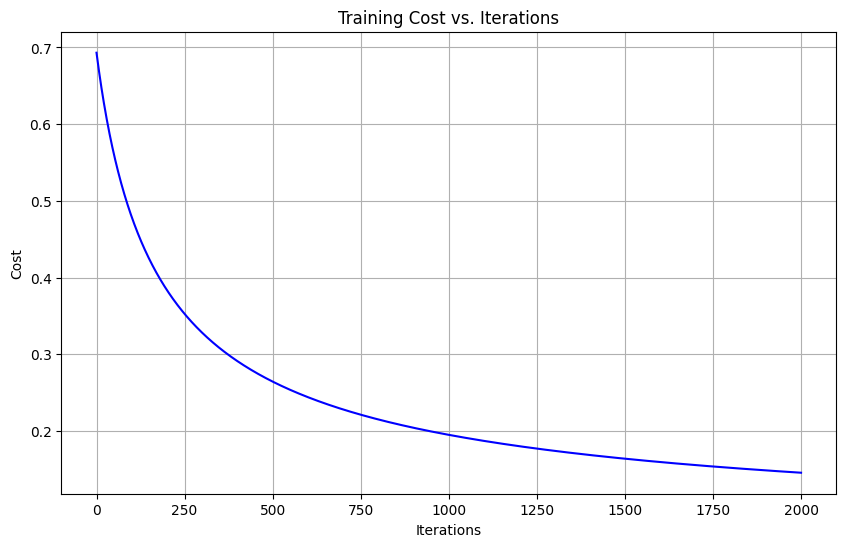

Training cost vs. iterations plot generated successfully.


In [ ]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for the plot
plt.figure(figsize=(10, 6))

# Plot the cost history against the number of iterations
# The x-axis represents the iteration number, and the y-axis represents the cost at that iteration.
plt.plot(range(custom_model.n_iterations), custom_model.cost_history, color='blue')

# Add a title to the plot for clarity
plt.title('Training Cost vs. Iterations')

# Label the x-axis
plt.xlabel('Iterations')

# Label the y-axis
plt.ylabel('Cost')

# Add a grid to the plot for better readability of the cost reduction over iterations
plt.grid(True)

# Display the plot
plt.show()

print("Training cost vs. iterations plot generated successfully.")

## Evaluate Custom Model Accuracy

### Subtask:
Make predictions on the `X_test_final` dataset using the trained custom `LogisticRegressionCustom` model and calculate its accuracy. The code will include comments explaining the evaluation process and results.


**Reasoning**:
I will make predictions on the test set using the custom Logistic Regression model and calculate its accuracy, following the instructions provided.



In [ ]:
from sklearn.metrics import accuracy_score

print('Evaluating Custom Logistic Regression Model...')

# Convert X_test_final (which is a Pandas DataFrame) to a NumPy array
# This ensures compatibility with the custom model's predict method which expects NumPy arrays.
X_test_np = X_test_final.values

# Make predictions on the test set using the trained custom model
# The predict method returns binary labels (0 or 1).
y_pred_custom = custom_model.predict(X_test_np)

# Calculate the accuracy of the custom model
# This compares the predicted labels with the true labels from the test set.
custom_model_accuracy = accuracy_score(y_test, y_pred_custom)

# Print the accuracy of the custom model
print(f"Custom Logistic Regression Model Accuracy on Test Set: {custom_model_accuracy:}")

Evaluating Custom Logistic Regression Model...
Custom Logistic Regression Model Accuracy on Test Set: 0.9736842105263158


## Final Task

### Subtask:
Summarize the implementation and evaluation of the custom logistic regression model, highlighting key findings and comparing it with the scikit-learn model if applicable.


## Summary:

### Data Analysis Key Findings
*   **Custom Logistic Regression Model Implementation**: A `LogisticRegressionCustom` class was successfully implemented, including `__init__`, `fit` (using gradient descent with `0.01` learning rate over `2000` iterations), and `predict` methods. It also tracked the binary cross-entropy cost during training.
*   **Training Progress**: During the custom model's training, the initial cost was approximately `0.6931` (at iteration 0), which steadily decreased to approximately `0.1519` by iteration `1800`, indicating successful optimization by gradient descent.
*   **Training Cost Visualization**: A plot of "Training Cost vs. Iterations" was generated, visually confirming the reduction in cost over the `2000` iterations, demonstrating the model's learning process.
*   **Custom Model Performance**: The custom Logistic Regression model achieved an accuracy of `0.9737` on the unseen test set (`X_test_final`), demonstrating its effectiveness in classifying breast cancer diagnoses.

### Insights or Next Steps
*   The high accuracy of the custom logistic regression model (\~97.4%) on the test set suggests that the implemented gradient descent algorithm is effective and the chosen features are strong predictors.
*   A direct comparison of the custom model's performance (accuracy, precision, recall, F1-score) with a standard `scikit-learn` Logistic Regression model on the same dataset would provide valuable context and validate the custom implementation's efficiency and accuracy relative to an optimized library version.


#comparing accuracy for custom model and sklearn model
  Accuracy: 0.973684210526315 for sklearn model
  Accuracy on Test Set: 0.9736842105263158

  which is almost the same coz , I have used robust scalar which might generalised compared to standard scalar and we must understand that , this is what sklearn model does internally which is the custom model..

In [ ]:
# Get the number of features from the final training data
n_features_final = X_train_final.shape[1]

# Generate 5 random samples for prediction
# The values are generated randomly and will then be scaled using the existing scaler.
np.random.seed(42) # for reproducibility
random_samples = np.random.rand(5, n_features_final) * 2 - 1 # Generate values between -1 and 1 to simulate scaled data

# Convert random_samples to a DataFrame to maintain column names for prediction, if needed, though custom model expects numpy.
# For consistency, we'll ensure it's a numpy array for the custom model.
random_samples_np = random_samples

print("Random Samples (scaled):")
print(random_samples_np)

#make predictions using sklearn model :
prediction = final_model.predict(random_samples_np)
print("\nPredictions for Random Samples (scikit-learn model):")
print(prediction)

# Make predictions using the custom logistic regression model
predictions_random_samples = custom_model.predict(random_samples_np)

print("\nPredictions for Random Samples (custom model):")
print(predictions_random_samples)

# For randomly generated samples, there are no 'actual' target values to compare against.
# These predictions are purely based on the learned model parameters.

# Interpretation of predictions
# 0 typically means Benign, 1 means Malignant
print("\nInterpretation: 0 = Benign, 1 = Malignant")

Random Samples (scaled):
[[-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272 -0.68801096
  -0.88383278  0.73235229  0.20223002  0.41614516 -0.95883101  0.9398197
   0.66488528 -0.57532178 -0.63635007]
 [-0.63319098 -0.39151551  0.04951286 -0.13610996 -0.41754172  0.22370579
  -0.72101228 -0.4157107  -0.26727631 -0.08786003  0.57035192 -0.60065244
   0.02846888  0.18482914 -0.90709917]
 [ 0.2150897  -0.65895175 -0.86989681  0.89777107  0.93126407  0.6167947
  -0.39077246 -0.80465577  0.36846605 -0.11969501 -0.75592353 -0.00964618
  -0.93122296  0.8186408  -0.48244004]
 [ 0.32504457 -0.37657785  0.04013604  0.09342056 -0.63029109  0.93916926
   0.55026565  0.87899788  0.7896547   0.19579996  0.84374847 -0.823015
  -0.60803428 -0.90954542 -0.34933934]
 [-0.22264542 -0.45730194  0.65747502 -0.28649335 -0.43813098  0.08539217
  -0.71815155  0.60439396 -0.85089871  0.97377387  0.54448954 -0.60256864
  -0.98895577  0.63092286  0.41371469]]

Predictions for Random Samples (scikit-lea

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
